<a href="https://colab.research.google.com/github/Joydrip/ASD-Detection-using-YOLOv5-BiLSTM/blob/main/ASD_Colab_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mtcnn tqdm scikit-learn opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.6 MB/s eta 0:00:00


In [ ]:
import os
import sys

base_path = "/content/drive/MyDrive/ASD facial Data"

asd_path = os.path.join(base_path, "ASD")
nonasd_path = os.path.join(base_path, "Non-ASD")

In [ ]:
print("\n===== ORIGINAL DATASET SUMMARY =====\n")
sys.stdout.flush()

# ASD
asd_persons = os.listdir(asd_path)
print("ASD persons:", len(asd_persons))

asd_image_count = 0
asd_video_count = 0

for person in asd_persons:
    p = os.path.join(asd_path, person)

    img_folder = os.path.join(p, "Image")
    vid_folder = os.path.join(p, "Video")

    if os.path.exists(img_folder):
        imgs = [f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg','.png','.jpeg'))]
        asd_image_count += len(imgs)

    if os.path.exists(vid_folder):
        vids = [f for f in os.listdir(vid_folder) if f.lower().endswith(('.mp4','.avi','.mov'))]
        asd_video_count += len(vids)

print("Total ASD still images:", asd_image_count)
print("Total ASD videos:", asd_video_count)


# Non-ASD
nonasd_persons = os.listdir(nonasd_path)
print("\nNon-ASD persons:", len(nonasd_persons))

nonasd_image_count = 0

for person in nonasd_persons:
    p = os.path.join(nonasd_path, person)
    imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.png','.jpeg'))]
    nonasd_image_count += len(imgs)

print("Total Non-ASD images:", nonasd_image_count)


===== ORIGINAL DATASET SUMMARY =====

ASD persons: 23
Total ASD still images: 22
Total ASD videos: 23

Non-ASD persons: 16
Total Non-ASD images: 203


In [ ]:
print("\n===== STRUCTURE PREVIEW =====\n")

for category in ["ASD", "Non-ASD"]:
    cat_path = os.path.join(base_path, category)
    persons = os.listdir(cat_path)[:3]   # show first 3

    print(category)
    for p in persons:
        person_path = os.path.join(cat_path, p)
        print("  ", p, "->", os.listdir(person_path))
    print()


===== STRUCTURE PREVIEW =====

ASD
   Ananya Chatterjee -> ['Video', 'Image', 'temp_frames']
   Arunima Mukherjee -> ['Video', 'Image', 'temp_frames']
   Vhaswar Chakraborty -> ['Video', 'Image', 'temp_frames']

Non-ASD
   varun -> ['varun2.jpeg', 'varun4.jpeg', 'varun13.jpeg', 'varun1.jpeg', 'varun3.jpeg', 'varun12.jpeg', 'varun6.jpeg', 'varun7.jpeg', 'varun9.jpeg', 'varun10.jpeg', 'varun8.jpeg', 'varun5.jpeg', 'varun14.jpeg']
   simran -> ['simran_14.jpeg', 'simran_4.jpeg', 'simran_12.jpeg', 'simran_5.jpeg', 'simran_11.jpeg', 'simran_1.jpeg', 'simran_13.jpeg', 'simran_3.jpeg', 'simran_9.jpeg', 'simran_7.jpeg', 'simran_10.jpeg', 'simran_8.jpeg', 'simran_6.jpeg', 'simran_2.jpeg']
   shubh -> ['shubh_7.jpg', 'shubh_8.jpg', 'shubh_14.jpg', 'shubh_10.jpg', 'shubh_9.jpg', 'shubh_4.jpg', 'shubh_5.jpg', 'shubh_3.jpg', 'shubh_1.jpg', 'shubh_6.jpg', 'shubh_11.jpg', 'shubh_2.jpg']



In [ ]:
def show_blurred_samples(folder_path, title, n=6, blur_level=75):
    """
    Displays blurred sample images from a folder (including subfolders)

    Parameters:
    folder_path : root folder
    title       : plot title
    n           : number of images to show
    blur_level  : odd number (higher = more blur)
    """

    # Collect all image paths
    image_paths = []
    for root, _, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, f))

    if len(image_paths) == 0:
        print("No images found in:", folder_path)
        return

    samples = random.sample(image_paths, min(n, len(image_paths)))

    plt.figure(figsize=(12,4))
    plt.suptitle(title, fontsize=14)

    for i, img_path in enumerate(samples):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply Gaussian Blur
        blurred = cv2.GaussianBlur(img, (blur_level, blur_level), 0)

        plt.subplot(1, len(samples), i+1)
        plt.imshow(blurred)
        plt.axis('off')

    plt.show()

Input


Blurred ASD samples


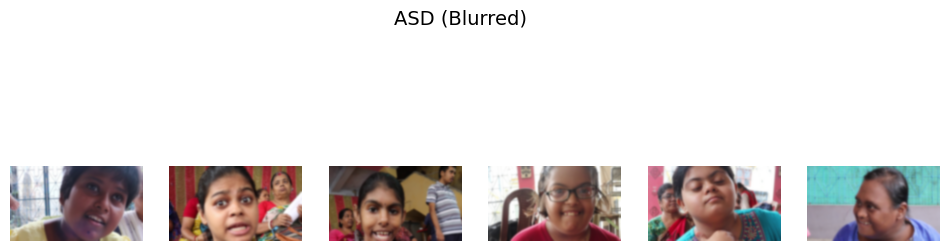

Blurred Non-ASD samples


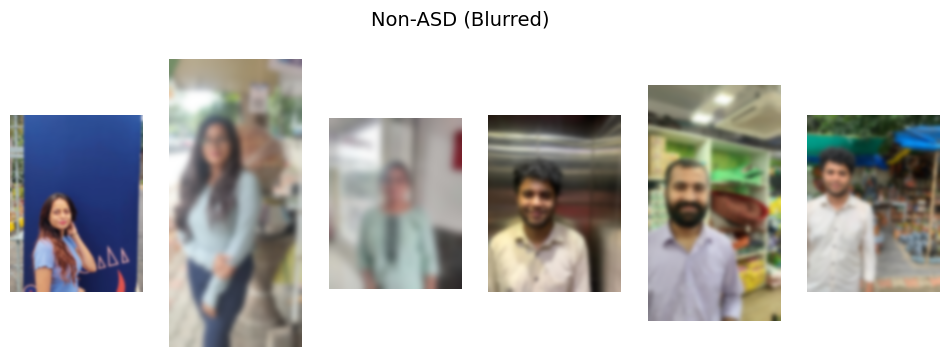

In [ ]:
base_path = "/content/drive/MyDrive/ASD facial Data"

print("Blurred ASD samples")
show_blurred_samples(os.path.join(base_path, "ASD"), "ASD (Blurred)")

print("Blurred Non-ASD samples")
show_blurred_samples(os.path.join(base_path, "Non-ASD"), "Non-ASD (Blurred)")

In [ ]:
import os

print("MyDrive contents:")
print(os.listdir("/content/drive/MyDrive"))

print("\nASD facial Data contents:")
print(os.listdir("/content/drive/MyDrive/ASD facial Data"))


MyDrive contents:
['Colab Notebooks', 'IMG-20250208-WA0069.jpg', 'Screenshot_20210306-163738.png', 'WIN_20211124_20_28_30_Pro.jpg', 'JEE main 2023 Final Score Card.pdf', 'Joydeep XII Marksheet Certificate.pdf', 'Gati Shakti Admission Fee.pdf', 'Classroom', 'assignment phy 1.pdf', '20230808_211945.heic', 'Abstract for conference (Sec-D).pdf', 'ESP I_Assignment I_DKD.gdoc', 'Abstract for conference (Sec-D).docx', 'Works', 'Joydeep Sarkar Poster (1).pptx', 'WhatsApp Image 2023-09-14 at 7.16.31 PM.jpeg', 'Template for Assignment and Project Submission 2023 batch july 23 02-1 (1) (1).docx', 'aadhar.pdf', 'Image to PDF 20231013 13.26.04.pdf', 'swapnil aadhar.pdf', 'swapnil pan.pdf', 'Document 8.pdf', 'Document 9.pdf', 'InnoDecor survey.gform', 'Achevements', 'Entrepreneurship Project Innodecor Milestone 1', 'Entrepreneurship Project Innodecor Milestone 2', 'Achievement 1', 'Amit_23_Anjan_72_Ridhi_45_Srishti_14_Abhinav21.gdoc', 'Template for Assignment and Project Submission 2023 batch july 2

Augmentation


In [ ]:
# ============================================================
# STEP 1: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# STEP 2: Imports & Paths
# ============================================================
import os
import cv2
import numpy as np
import shutil
import random
import sys

base_path = "/content/drive/MyDrive/ASD facial Data"
asd_path = os.path.join(base_path, "ASD")
nonasd_path = os.path.join(base_path, "Non-ASD")

processed_path = "/content/Processed_ASD_Data"
train_path = os.path.join(processed_path, "train")
test_path = os.path.join(processed_path, "test")

frames_per_video = 18   # 15–20 equal frames
face_size = (224, 224)
test_split = 0.2

# Create output folders
for path in [train_path, test_path]:
    for cls in ["ASD", "Non-ASD"]:
        os.makedirs(os.path.join(path, cls), exist_ok=True)

print("Folders created.")
sys.stdout.flush()

# ============================================================
# STEP 3: Face Detector (Haar)
# ============================================================
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detect_and_process_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        return None

    # Take largest face
    x, y, w, h = max(faces, key=lambda f: f[2]*f[3])

    face = img[y:y+h, x:x+w]

    # Background blur
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    mask[y:y+h, x:x+w] = 255
    blurred = cv2.GaussianBlur(img, (51,51), 0)
    img[mask == 0] = blurred[mask == 0]

    face = cv2.resize(face, face_size)
    return face

# ============================================================
# STEP 4: Helper – Save images per person
# ============================================================
def save_images(images, label, person_name):
    # Person-wise split
    random.shuffle(images)
    split = int(len(images) * (1 - test_split))
    train_imgs = images[:split]
    test_imgs = images[split:]

    for i, img in enumerate(train_imgs):
        cv2.imwrite(f"{train_path}/{label}/{person_name}_{i}.jpg", img)

    for i, img in enumerate(test_imgs):
        cv2.imwrite(f"{test_path}/{label}/{person_name}_{i}.jpg", img)

# ============================================================
# STEP 5: Process ASD (Images + Videos)
# ============================================================
print("\nProcessing ASD...")
sys.stdout.flush()

asd_persons = [p for p in os.listdir(asd_path) if os.path.isdir(os.path.join(asd_path,p))]
print("Total ASD persons:", len(asd_persons))
sys.stdout.flush()

for person in asd_persons:
    person_path = os.path.join(asd_path, person)
    collected = []

    print(f"\nASD Person: {person}")
    sys.stdout.flush()

    # ---------- Images ----------
    image_folder = os.path.join(person_path, "Image")
    if os.path.exists(image_folder):
        imgs = os.listdir(image_folder)
        print(" Images:", len(imgs))
        sys.stdout.flush()

        for img_name in imgs:
            img_path = os.path.join(image_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            face = detect_and_process_face(img)
            if face is not None:
                collected.append(face)

    # ---------- Videos ----------
    video_folder = os.path.join(person_path, "Video")
    if os.path.exists(video_folder):
        videos = os.listdir(video_folder)
        print(" Videos:", len(videos))
        sys.stdout.flush()

        for vid_name in videos:
            vid_path = os.path.join(video_folder, vid_name)
            print("  Processing video:", vid_name)
            sys.stdout.flush()

            cap = cv2.VideoCapture(vid_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            if total_frames == 0:
                cap.release()
                continue

            indices = np.linspace(
                0, total_frames-1,
                min(frames_per_video, total_frames),
                dtype=int
            )

            for idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if not ret:
                    continue

                face = detect_and_process_face(frame)
                if face is not None:
                    collected.append(face)

            cap.release()

    print(" Total faces collected:", len(collected))
    sys.stdout.flush()

    if len(collected) > 0:
        save_images(collected, "ASD", person)

# ============================================================
# STEP 6: Process Non-ASD
# ============================================================
print("\nProcessing Non-ASD...")
sys.stdout.flush()

nonasd_persons = [p for p in os.listdir(nonasd_path) if os.path.isdir(os.path.join(nonasd_path,p))]
print("Total Non-ASD persons:", len(nonasd_persons))
sys.stdout.flush()

for person in nonasd_persons:
    person_path = os.path.join(nonasd_path, person)
    collected = []

    print(f"\nNon-ASD Person: {person}")
    sys.stdout.flush()

    images = os.listdir(person_path)
    print(" Images:", len(images))
    sys.stdout.flush()

    for img_name in images:
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        face = detect_and_process_face(img)
        if face is not None:
            collected.append(face)

    print(" Total faces collected:", len(collected))
    sys.stdout.flush()

    if len(collected) > 0:
        save_images(collected, "Non-ASD", person)

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n=================================")
print("FULL PIPELINE COMPLETED")
print("Processed data saved at:", processed_path)
print("Train/Test split done person-wise (no leakage)")
print("Frames per video:", frames_per_video)
print("=================================")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders created.

Processing ASD...
Total ASD persons: 23

ASD Person: Ananya Chatterjee
 Images: 1
 Videos: 1
  Processing video: 1.Ananya Chatterjee.mp4
 Total faces collected: 4

ASD Person: Arunima Mukherjee
 Images: 1
 Videos: 1
  Processing video: Copy of 3.Arunima Mukherjee.mp4
 Total faces collected: 14

ASD Person: Vhaswar Chakraborty
 Images: 1
 Videos: 1
  Processing video: Copy of 5.Bhaswar Chakraborty.mp4
 Total faces collected: 8

ASD Person: Anirban Bhattacharya
 Images: 1
 Videos: 1
  Processing video: Copy of 2.Anirban Bhattacharya.mp4
 Total faces collected: 19

ASD Person: Avinash Shaw
 Images: 1
 Videos: 1
  Processing video: Copy of 4.Avinash Shaw.mp4
 Total faces collected: 15

ASD Person: Deepa Roy
 Images: 1
 Videos: 1
  Processing video: Copy of 6.Deepa Roy.mp4
 Total faces collected: 19

ASD Person: Nabanita Das
 Images: 1
 Videos: 1

In [ ]:
import os

train_path = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/train"
test_path = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/test"

train_files = set()
test_files = set()

for cls in ["ASD", "Non-ASD"]:
    for f in os.listdir(os.path.join(train_path, cls)):
        train_files.add(f.split("_")[0])

    for f in os.listdir(os.path.join(test_path, cls)):
        test_files.add(f.split("_")[0])

common = train_files.intersection(test_files)

print("Persons appearing in both:", common)


Persons appearing in both: set()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

base_path = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit"

splits = ["train", "test"]
classes = ["ASD", "Non-ASD"]

total_asd = 0
total_nonasd = 0

print("Counting images...")
sys.stdout.flush()

for split in splits:
    print(f"\n--- {split.upper()} ---")
    sys.stdout.flush()

    for cls in classes:
        folder = os.path.join(base_path, split, cls)

        if not os.path.exists(folder):
            print(f"{split}/{cls} not found")
            continue

        files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        count = len(files)
        print(f"{cls}: {count}")
        sys.stdout.flush()

        if cls == "ASD":
            total_asd += count
        else:
            total_nonasd += count

print("\n=================================")
print("TOTAL ASD images:", total_asd)
print("TOTAL Non-ASD images:", total_nonasd)
print("TOTAL DATASET SIZE:", total_asd + total_nonasd)
print("=================================")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Counting images...

--- TRAIN ---
ASD: 146
Non-ASD: 107

--- TEST ---
ASD: 53
Non-ASD: 41

TOTAL ASD images: 199
TOTAL Non-ASD images: 148
TOTAL DATASET SIZE: 347


In [ ]:
train_dir = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/train"
test_dir  = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/test"


In [ ]:
train_path = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/train"

In [ ]:
print("===== TRAIN DATASET DETAILS =====\n")
sys.stdout.flush()

classes = ["ASD", "Non-ASD"]
total = 0

for cls in classes:
    cls_path = os.path.join(train_path, cls)

    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    count = len(images)
    total += count

    print(f"{cls}: {count} images")
    sys.stdout.flush()

print("\nTotal training images:", total)

===== TRAIN DATASET DETAILS =====



NameError: name 'sys' is not defined

In [ ]:
def blur_full_image(image, blur_level=35):
    # blur_level must be odd
    return cv2.GaussianBlur(image, (blur_level, blur_level), 0)

In [ ]:
def show_blurred_samples(folder, title, n=6):
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(images) == 0:
        print("No images in:", folder)
        return

    samples = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(12,4))
    plt.suptitle(title, fontsize=14)

    for i, img_name in enumerate(samples):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = blur_full_image(img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(samples), i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.show()


Showing fully blurred samples...

Displaying: Train/ASD


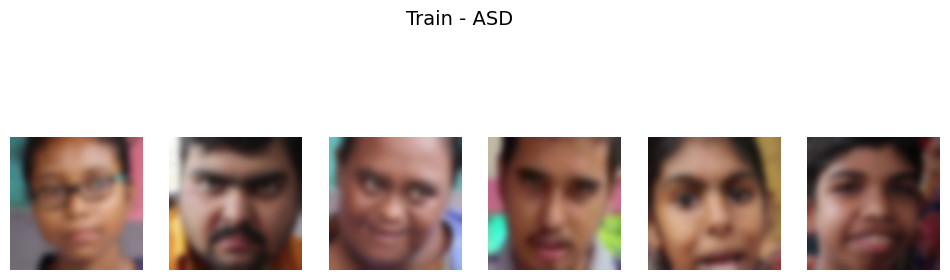

Displaying: Train/Non-ASD


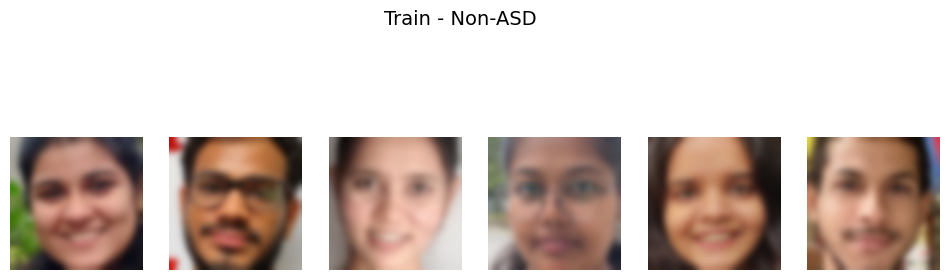

In [ ]:
print("\nShowing fully blurred samples...\n")

for cls in ["ASD", "Non-ASD"]:
    cls_path = os.path.join(train_path, cls)
    print(f"Displaying: Train/{cls}")
    sys.stdout.flush()
    show_blurred_samples(cls_path, f"Train - {cls}")

In [ ]:
test_path = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/test"


Showing fully blurred TEST samples...

Displaying: Test/ASD


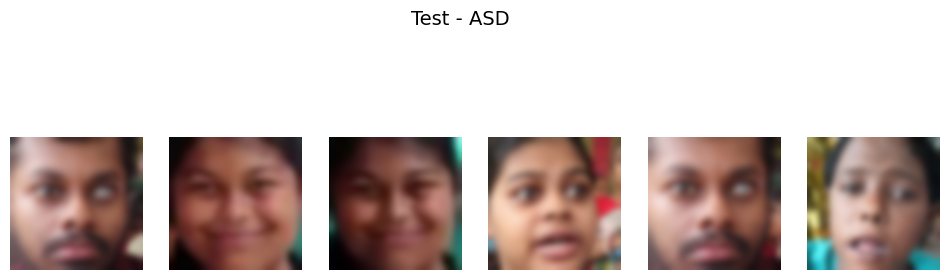

Displaying: Test/Non-ASD


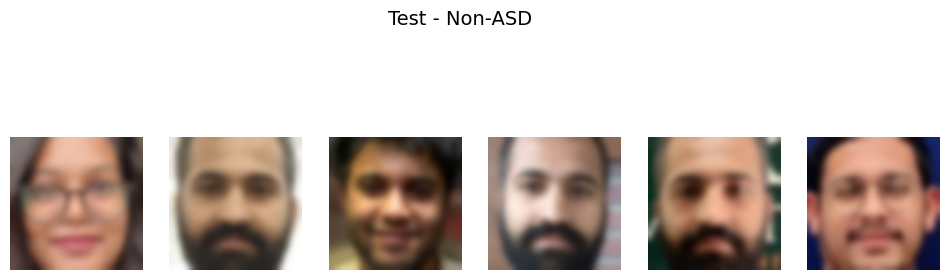

In [ ]:
print("\nShowing fully blurred TEST samples...\n")

for cls in ["ASD", "Non-ASD"]:
    cls_path = os.path.join(test_path, cls)
    print(f"Displaying: Test/{cls}")
    sys.stdout.flush()
    show_blurred_samples(cls_path, f"Test - {cls}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling1D, Reshape,
                                     LayerNormalization, MultiHeadAttention, Add)
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

In [ ]:
!pip install -q tensorflow scikit-learn matplotlib seaborn

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import *
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
train_dir = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/train"
test_dir  = "/content/drive/MyDrive/Processed_ASD_Data_GroupSplit/test"

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8   # EfficientNetB4 is heavy

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class mapping:", train_gen.class_indices)

Found 251 images belonging to 2 classes.
Found 93 images belonging to 2 classes.
Class mapping: {'ASD': 0, 'Non-ASD': 1}


In [ ]:
# Input
inputs = Input(shape=(224, 224, 3))

# EfficientNetB4 Backbone
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)

# Freeze backbone (important for small dataset)
for layer in base_model.layers:
    layer.trainable = False

# Feature map: (7, 7, 1792)
x = base_model.output

# Convert to 49 tokens (7x7)
x = Reshape((49, 1792))(x)

# -------- ViT Head --------

# Layer Normalization
x_norm = LayerNormalization()(x)

# Multi-Head Self Attention
attention_output = MultiHeadAttention(
    num_heads=8,
    key_dim=64
)(x_norm, x_norm)

# Residual connection
x = Add()([x, attention_output])

# Global context aggregation
x = GlobalAveragePooling1D()(x)

# -------- Classification Head --------

x = BatchNormalization()(x)

x = Dense(256, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = Dropout(0.4)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 21,849,952 (83.35 MB)

 Trainable params: 4,172,545 (15.92 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
history = model.fit(
    train_gen,
    epochs=8,
    validation_data=test_gen,
    callbacks=callbacks
)

Epoch 1/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.5163 - auc: 0.5041 - loss: 0.9005 - val_accuracy: 0.7849 - val_auc: 0.8565 - val_loss: 0.7331 - learning_rate: 3.0000e-05
Epoch 2/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.5464 - auc: 0.5231 - loss: 0.9185 - val_accuracy: 0.7312 - val_auc: 0.8572 - val_loss: 0.7324 - learning_rate: 3.0000e-05
Epoch 3/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.5468 - auc: 0.5522 - loss: 0.8628 - val_accuracy: 0.7527 - val_auc: 0.8537 - val_loss: 0.7251 - learning_rate: 3.0000e-05
Epoch 4/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.4781 - auc: 0.4609 - loss: 0.9468 - val_accuracy: 0.6774 - val_auc: 0.8628 - val_loss: 0.7190 - learning_rate: 3.0000e-05
Epoch 5/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.6067 - auc: 0.6233 - loss: 0.7840 - val_accuracy: 0.5699 - val_auc: 0.8682 - val_loss: 0.7126 - learning_rate: 3.0000e-05
Epoch 6/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.5858 - auc: 

Generating predictions...


12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step

===== Detailed Metrics =====
Accuracy      : 0.5699
Precision     : 1.0000
Recall (Sens) : 0.0244
Specificity   : 1.0000
F1 Score      : 0.0476
ROC AUC       : 0.8663
PR AUC        : 0.8106
MCC           : 0.1174

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.57      1.00      0.72        52
           1       1.00      0.02      0.05        41

    accuracy                           0.57        93
   macro avg       0.78      0.51      0.38        93
weighted avg       0.76      0.57      0.42        93

Confusion Matrix
[[52  0]
 [40  1]]


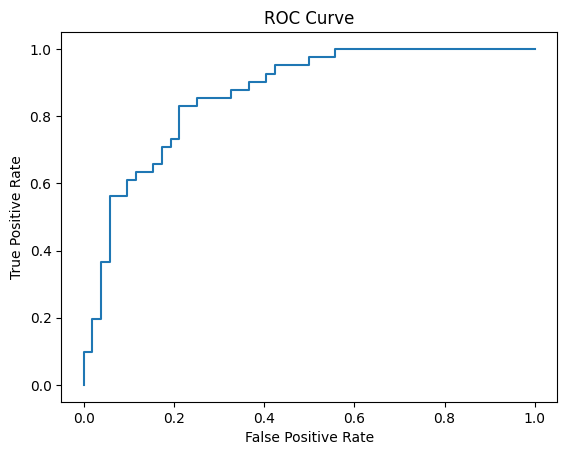

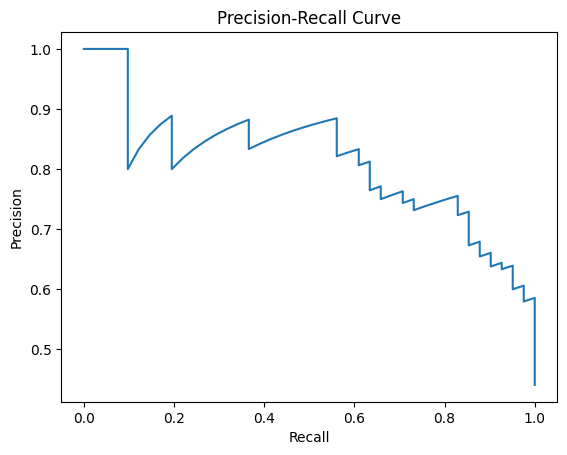

In [ ]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

print("Generating predictions...")
pred_probs = model.predict(test_gen)
preds = (pred_probs > 0.5).astype(int).ravel()
true_labels = test_gen.classes

# =========================
# Basic Metrics
# =========================
accuracy = accuracy_score(true_labels, preds)
precision = precision_score(true_labels, preds)
recall = recall_score(true_labels, preds)
f1 = f1_score(true_labels, preds)
roc_auc = roc_auc_score(true_labels, pred_probs)
mcc = matthews_corrcoef(true_labels, preds)

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
tn, fp, fn, tp = cm.ravel()

# Medical Metrics
specificity = tn / (tn + fp)
sensitivity = recall   # same as recall

# Precision-Recall AUC
precision_curve, recall_curve, _ = precision_recall_curve(true_labels, pred_probs)
pr_auc = auc(recall_curve, precision_curve)

print("\n===== Detailed Metrics =====")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall (Sens) : {sensitivity:.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC AUC       : {roc_auc:.4f}")
print(f"PR AUC        : {pr_auc:.4f}")
print(f"MCC           : {mcc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(true_labels, preds))

print("Confusion Matrix")
print(cm)

# =========================
# ROC Curve
# =========================
fpr, tpr, _ = roc_curve(true_labels, pred_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# =========================
# Precision-Recall Curve
# =========================
plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()